# Proyecto Integrador - Módulo 5

## Notebook 2: Comprensión y Análisis Exploratorio de Datos (EDA)

## Objetivo

El objetivo de este notebook es comprender la estructura y calidad del conjunto de datos mediante un análisis exploratorio (EDA). Durante esta etapa se realizará la caracterización de las variables, la identificación de valores nulos, la revisión de los tipos de datos y el análisis univariable, bivariable y multivariable.

Los hallazgos obtenidos permitirán comprender el comportamiento de la información, detectar posibles problemas de calidad de los datos e identificar posibles transformaciones que serán utilizadas en las siguientes etapas del proyecto de Machine Learning.

## Importación de librerías

In [2]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import kurtosis

# Configuración de visualización
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 1. Carga del conjunto de datos

In [3]:
# ==========================================
# CARGA DEL DATASET
# ==========================================

ruta_datos = "../Base_de_datos.xlsx"

df = pd.read_excel(ruta_datos)

## 1.1 Exploración inicial del conjunto de datos
En esta sección se realiza una revisión general del dataset para conocer su estructura, dimensiones y composición. El objetivo es obtener una primera visión de la información disponible antes de iniciar el análisis exploratorio detallado.

In [4]:
# ==========================================
# DIMENSIONES DEL DATASET
# ==========================================

print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 10763
Número de variables: 23


## 1.2 Información general del conjunto de datos

En esta sección se analiza la estructura general del dataset mediante la revisión de las variables, sus tipos de datos y la presencia de valores nulos. Esta información permite identificar posibles ajustes necesarios antes de realizar el análisis exploratorio.

In [5]:
# ==========================================
# INFORMACIÓN GENERAL DEL DATASET
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

In [ ]:
# ==========================================
# INFORMACIÓN GENERAL DEL DATASET
# ==========================================

df.head(15)

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1
5,4,2025-06-10 08:54:01,1031928.0,12,32,Empleado,2800000,800000,82872,95.227787,721.0,10,13,0.0,24399.0,24399.0,0.0,2,0,8,2808474.0,Creciente,1
6,4,2025-08-09 13:00:44,3064280.4,6,68,Independiente,1000000,22005000,461231,95.227787,814.0,11,8,0.0,211775.0,211775.0,0.0,6,3,0,969508.0,Creciente,1
7,4,2025-08-18 12:49:19,3619560.0,6,31,Empleado,3782303,305000,542079,95.227787,760.0,1,5,0.0,12078.0,12078.0,0.0,0,1,0,3782303.0,Creciente,1
8,9,2025-05-30 09:11:18,2134827.6,10,31,Empleado,14500000,8000000,181732,95.227787,737.0,0,2,0.0,0.0,NaN,NaN,0,0,0,14007850.0,Creciente,1
9,4,2024-12-31 14:32:59,8400000.0,6,45,Empleado,14000000,5000000,1166667,95.227787,752.0,4,3,0.0,125383.0,125383.0,0.0,2,0,0,28889623.0,Creciente,1


### Interpretación

El conjunto de datos está conformado por **23 variables**, las cuales incluyen información del crédito, características del cliente y variables relacionadas con su comportamiento financiero.

Se identifican cuatro tipos de datos:

- Variables numéricas enteras (`int64`)
- Variables numéricas decimales (`float64`)
- Variables categóricas (`object`)
- Variables de fecha (`datetime64[ns]`)

Adicionalmente, la salida de `df.info()` evidencia que algunas variables no contienen la totalidad de los registros, lo que indica la presencia de valores nulos. Su cantidad y distribución serán analizadas en la siguiente sección.

In [6]:
# ==========================================
# TIPOS DE DATOS POR VARIABLE
# ==========================================

tipos_datos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.values
})

tipos_datos

,Variable,Tipo de dato
0,tipo_credito,int64
1,fecha_prestamo,datetime64[ns]
2,capital_prestado,float64
3,plazo_meses,int64
4,edad_cliente,int64
5,tipo_laboral,object
6,salario_cliente,int64
7,total_otros_prestamos,int64
8,cuota_pactada,int64
9,puntaje,float64


## 1.3 Caracterización de las variables

En esta sección se clasifican las variables según su naturaleza y tipo de información. Esta caracterización facilita la selección de las técnicas de análisis y visualización que se utilizarán durante el EDA.

In [10]:
caracterizacion = pd.DataFrame({
    "Variable": [
        "tipo_credito",
        "fecha_prestamo",
        "capital_prestado",
        "plazo_meses",
        "edad_cliente",
        "tipo_laboral",
        "salario_cliente",
        "total_otros_prestamos",
        "cuota_pactada",
        "puntaje",
        "puntaje_datacredito",
        "cant_creditosvigentes",
        "huella_consulta",
        "saldo_mora",
        "saldo_total",
        "saldo_principal",
        "saldo_mora_codeudor",
        "creditos_sectorFinanciero",
        "creditos_sectorCooperativo",
        "creditos_sectorReal",
        "promedio_ingresos_datacredito",
        "tendencia_ingresos",
        "Pago_atiempo"
    ],

    "Clasificación": [
        "Categórica Nominal",
        "Fecha",
        "Numérica Continua",
        "Numérica Discreta",
        "Numérica Discreta",
        "Categórica Nominal",
        "Numérica Continua",
        "Numérica Discreta",
        "Numérica Continua",
        "Numérica Continua",
        "Numérica Continua",
        "Numérica Discreta",
        "Numérica Discreta",
        "Numérica Continua",
        "Numérica Continua",
        "Numérica Continua",
        "Numérica Continua",
        "Numérica Discreta",
        "Numérica Discreta",
        "Numérica Discreta",
        "Numérica Continua",
        "Categórica Ordinal",
        "Categóroca Dicotómica"
    ]
})

caracterizacion

,Variable,Clasificación
0,tipo_credito,Categórica Nominal
1,fecha_prestamo,Fecha
2,capital_prestado,Numérica Continua
3,plazo_meses,Numérica Discreta
4,edad_cliente,Numérica Discreta
5,tipo_laboral,Categórica Nominal
6,salario_cliente,Numérica Continua
7,total_otros_prestamos,Numérica Discreta
8,cuota_pactada,Numérica Continua
9,puntaje,Numérica Continua


### Interpretación

La mayoría de las variables presentan un tipo de dato consistente con la información que representan. Sin embargo, se identificó que la variable **tendencia_ingresos** contiene valores numéricos, valores categóricos y registros vacíos, lo que evidencia una inconsistencia en la estructura de los datos.

Esta variable requerirá un análisis más detallado durante la etapa de limpieza para definir el tratamiento más adecuado y garantizar la uniformidad de la información.

## 1.4 Revisión de valores nulos

En esta sección se identifica la cantidad y el porcentaje de valores nulos presentes en cada variable del conjunto de datos. Este análisis permite determinar el impacto que pueden tener los datos faltantes y definir posteriormente la estrategia de tratamiento más adecuada.

In [11]:
# ==========================================
# REVISIÓN DE VALORES NULOS
# ==========================================

nulos = pd.DataFrame({
    "Valores nulos": df.isnull().sum(),
    "Porcentaje (%)": round((df.isnull().sum() / len(df)) * 100, 2)
})

nulos = nulos[nulos["Valores nulos"] > 0]

nulos.sort_values(by="Porcentaje (%)", ascending=False)

,Valores nulos,Porcentaje (%)
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


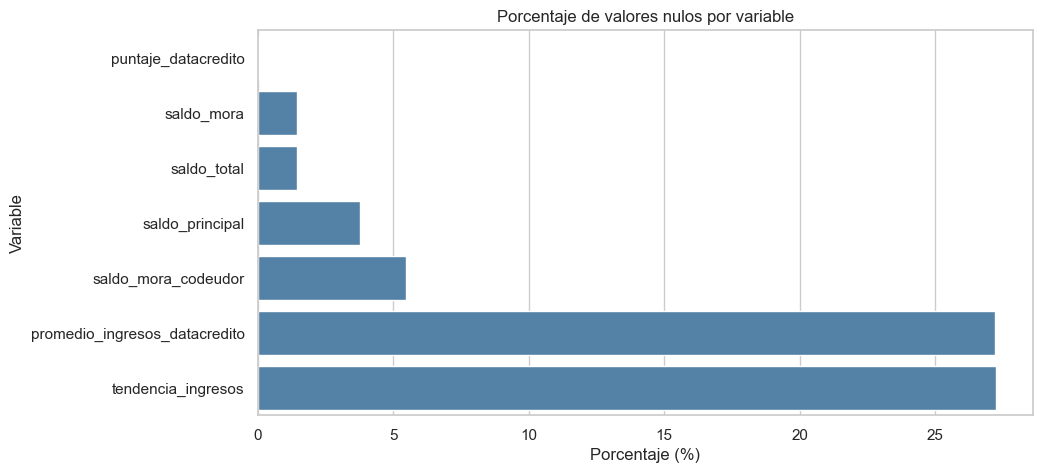

In [14]:
# ==========================================
# VISUALIZACIÓN DE VALORES NULOS
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(
    x=nulos["Porcentaje (%)"],
    y=nulos.index,
    color ="steelblue"
)

plt.title("Porcentaje de valores nulos por variable")
plt.xlabel("Porcentaje (%)")
plt.ylabel("Variable")

plt.show()

### Interpretación

Se identificó que **7 de las 23 variables** presentan valores nulos, aunque el impacto no es uniforme entre ellas.

Las variables **tendencia_ingresos** (27,24 %) y **promedio_ingresos_datacredito** (27,22 %) concentran la mayor proporción de datos faltantes, por lo que requerirán un análisis detallado para definir si los valores pueden imputarse o si representan información no disponible para determinados clientes.

Las variables **saldo_mora_codeudor** (5,48 %), **saldo_principal** (3,76 %), **saldo_mora** (1,45 %) y **saldo_total** (1,45 %) presentan porcentajes relativamente bajos de valores nulos, lo que sugiere que podrían ser tratadas mediante técnicas de imputación, dependiendo del contexto del negocio.

Finalmente, **puntaje_datacredito** presenta únicamente 6 registros faltantes (0,06 %), lo que representa un impacto mínimo sobre el conjunto de datos.

## 1.5 Verificación de la representación de valores nulos

Además de los valores nulos identificados por Pandas (`NaN`), es posible que algunas variables contengan registros que representen información faltante mediante cadenas de texto o símbolos especiales. En esta sección se verifica la existencia de estas representaciones para unificarlas posteriormente.

In [15]:
# ==========================================
# BÚSQUEDA DE POSIBLES REPRESENTACIONES DE NULOS
# ==========================================

representaciones_nulos = [
    "",
    " ",
    "NA",
    "N/A",
    "NULL",
    "null",
    "NaN",
    "Sin información",
    "No registra",
    "-"
]

for valor in representaciones_nulos:
    cantidad = (df == valor).sum().sum()
    print(f"{repr(valor):<20} -> {cantidad}")

''                   -> 0
' '                  -> 0
'NA'                 -> 0
'N/A'                -> 0
'NULL'               -> 0
'null'               -> 0
'NaN'                -> 0
'Sin información'    -> 0
'No registra'        -> 0
'-'                  -> 0


### Interpretación

Se verificó la existencia de posibles representaciones alternativas de valores faltantes, como cadenas vacías (`""`), espacios en blanco, "NA", "N/A", "NULL", "Sin información" y otros valores comúnmente utilizados para representar información ausente.

Los resultados indican que ninguna de estas representaciones está presente en el conjunto de datos. Por lo tanto, los valores faltantes se encuentran correctamente almacenados como `NaN`, lo que garantiza una representación uniforme y facilita su tratamiento en las etapas posteriores del proyecto.

## 2. Calidad y preparación inicial de los datos


## 2.1 Revisión de variables irrelevantes

En esta sección se analiza si existen variables que, por su naturaleza o contenido, no aporten información relevante para el desarrollo del modelo predictivo. Se evalúa cada atributo considerando su posible contribución a la predicción del riesgo crediticio.

In [16]:
# ==========================================
# LISTADO DE VARIABLES
# ==========================================

for i, columna in enumerate(df.columns, start=1):
    print(f"{i}. {columna}")

1. tipo_credito
2. fecha_prestamo
3. capital_prestado
4. plazo_meses
5. edad_cliente
6. tipo_laboral
7. salario_cliente
8. total_otros_prestamos
9. cuota_pactada
10. puntaje
11. puntaje_datacredito
12. cant_creditosvigentes
13. huella_consulta
14. saldo_mora
15. saldo_total
16. saldo_principal
17. saldo_mora_codeudor
18. creditos_sectorFinanciero
19. creditos_sectorCooperativo
20. creditos_sectorReal
21. promedio_ingresos_datacredito
22. tendencia_ingresos
23. Pago_atiempo


### Interpretación

Después de revisar cada una de las variables del conjunto de datos se identifico que todas las variables contienen información potencialmente útil para explicar el comportamiento crediticio de los clientes o servir como variables predictoras durante el entrenamiento del modelo. por lo que no se eliminará ninguna variable en esta etapa del análisis exploratorio.


## 2.2 Validación de tipos de datos

Se verificó que cada variable estuviera almacenada utilizando un tipo de dato consistente con la información que representa, garantizando así la correcta ejecución de los análisis exploratorios posteriores.

In [31]:
# ==========================================
# VALIDACIÓN DE TIPOS DE DATOS
# ==========================================

df.dtypes

tipo_credito                              int64
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                             object
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

### Interpretación

Se verificó que las variables del conjunto de datos presentan tipos de datos adecuados para el análisis:

- **fecha_prestamo** se encuentra almacenada como tipo `datetime`.
- Las variables numéricas corresponden a los tipos `int64` y `float64`.
- Las variables categóricas se encuentran representadas mediante el tipo `object`.


## 2.3 Revisión de registros duplicados

Se verifica la existencia de registros completamente duplicados dentro del conjunto de datos, ya que estos podrían afectar los resultados del análisis exploratorio y del modelo predictivo.

In [32]:
# ==========================================
# REVISIÓN DE REGISTROS DUPLICADOS
# ==========================================

duplicados = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

Registros duplicados encontrados: 0


### Interpretación

No se identificaron registros completamente duplicados dentro del conjunto de datos, por lo que no fue necesario eliminar observaciones antes de continuar con el análisis exploratorio.

## 2.4 Revisión de inconsistencias

Durante la exploración inicial se identificó una posible inconsistencia en la variable **tendencia_ingresos**, la cual contiene tanto categorías textuales como valores numéricos positivos y negativos.

En esta sección se analiza el contenido de la variable con el fin de comprender su estructura y determinar si requiere algún tratamiento durante la etapa de preparación de los datos.

In [33]:
# ==========================================
# REVISIÓN DE LA VARIABLE tendencia_ingresos
# ==========================================

df["tendencia_ingresos"].value_counts(dropna=False)

tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
75761             1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
4250635           1
146918            1
1123000           1
15090             1
10808             1
22363             1
-101368           1
86286             1
65988             1
77975             1
-288              1
54683             1
5697              1
122727            1
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
417087            1
209090            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
22832             1
-224714           1
Name: count, dtype: int64

In [34]:
df["tendencia_ingresos"].apply(type).value_counts()

tendencia_ingresos
<class 'str'>      7773
<class 'float'>    2932
<class 'int'>        58
Name: count, dtype: int64

### Interpretación

La revisión de la variable **tendencia_ingresos** permitió identificar una inconsistencia en la representación de sus datos.

Se observó que la columna contiene simultáneamente:

- categorías textuales (*Creciente*, *Decreciente* y *Estable*);
- valores numéricos enteros, tanto positivos como negativos;
- valores faltantes (`NaN`).

Aunque, por su nombre, la variable podría aportar información relevante para la predicción del riesgo crediticio, la inconsistencia identificada impide interpretar correctamente todos sus registros durante esta etapa del análisis exploratorio. Por esta razón, la variable se conserva sin modificaciones y la inconsistencia queda documentada como un hallazgo del proceso de exploración de datos.

# 4. Análisis univariable

El análisis univariable tiene como objetivo estudiar cada variable de manera individual para comprender su comportamiento, distribución y características estadísticas.

## 4.1 Variables numéricas

In [36]:
# ==========================================
# VARIABLES NUMÉRICAS
# ==========================================

variables_numericas = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Variables numéricas:")

for variable in variables_numericas:
    print("-", variable)

Variables numéricas:
- tipo_credito
- capital_prestado
- plazo_meses
- edad_cliente
- salario_cliente
- total_otros_prestamos
- cuota_pactada
- puntaje
- puntaje_datacredito
- cant_creditosvigentes
- huella_consulta
- saldo_mora
- saldo_total
- saldo_principal
- saldo_mora_codeudor
- creditos_sectorFinanciero
- creditos_sectorCooperativo
- creditos_sectorReal
- promedio_ingresos_datacredito
- Pago_atiempo


In [37]:
# ==========================================
# VARIABLES NUMÉRICAS PARA VISUALIZACIÓN
# ==========================================

variables_numericas_graficas = [
    variable for variable in variables_numericas
    if variable not in ["tipo_credito", "Pago_atiempo"]
]

print("Variables que se analizarán con histogramas y boxplots:")

for variable in variables_numericas_graficas:
    print("-", variable)

Variables que se analizarán con histogramas y boxplots:
- capital_prestado
- plazo_meses
- edad_cliente
- salario_cliente
- total_otros_prestamos
- cuota_pactada
- puntaje
- puntaje_datacredito
- cant_creditosvigentes
- huella_consulta
- saldo_mora
- saldo_total
- saldo_principal
- saldo_mora_codeudor
- creditos_sectorFinanciero
- creditos_sectorCooperativo
- creditos_sectorReal
- promedio_ingresos_datacredito


In [38]:
# ==========================================
# RESUMEN ESTADÍSTICO
# ==========================================

df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.0,5.411131e+00,2.338279e+00,4.00000,4.000000e+00,4.000000e+00,9.000000e+00,6.800000e+01
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01


In [39]:
# ==========================================
# ESTADÍSTICAS DESCRIPTIVAS
# ==========================================

estadisticas = pd.DataFrame({
    "Media": df[variables_numericas].mean(),
    "Mediana": df[variables_numericas].median(),
    "Moda": df[variables_numericas].mode().iloc[0],
    "Mínimo": df[variables_numericas].min(),
    "Máximo": df[variables_numericas].max(),
    "Rango": df[variables_numericas].max() - df[variables_numericas].min(),
    "Desv. Estándar": df[variables_numericas].std(),
    "Varianza": df[variables_numericas].var(),
    "Skewness": df[variables_numericas].skew(),
    "Kurtosis": df[variables_numericas].kurt()
})

estadisticas = estadisticas.round(2)

estadisticas

,Media,Mediana,Moda,Mínimo,Máximo,Rango,Desv. Estándar,Varianza,Skewness,Kurtosis
tipo_credito,5.41,4.00,4.00,4.00,6.800000e+01,6.400000e+01,2.340000e+00,5.470000e+00,2.67,46.46
capital_prestado,2434315.00,1921920.00,1200000.00,360000.00,4.144415e+07,4.108415e+07,1.909643e+06,3.646735e+12,3.72,35.32
plazo_meses,10.58,10.00,6.00,2.00,9.000000e+01,8.800000e+01,6.630000e+00,4.398000e+01,2.46,7.78
edad_cliente,43.95,42.00,40.00,19.00,1.230000e+02,1.040000e+02,1.506000e+01,2.268300e+02,1.93,7.87
salario_cliente,17216431.46,3000000.00,3000000.00,0.00,2.200000e+10,2.200000e+10,3.554767e+08,1.263637e+17,43.78,2211.23
total_otros_prestamos,6238869.65,1000000.00,2000000.00,0.00,6.787675e+09,6.787675e+09,1.184183e+08,1.402290e+16,38.46,1719.28
cuota_pactada,243617.41,182863.00,205990.00,23944.00,3.816752e+06,3.792808e+06,2.104937e+05,4.430760e+10,3.79,26.65
puntaje,91.17,95.23,95.23,-38.01,9.523000e+01,1.332400e+02,1.647000e+01,2.711100e+02,-4.87,24.08
puntaje_datacredito,780.79,791.00,0.00,-7.00,9.990000e+02,1.006000e+03,1.048800e+02,1.099940e+04,-5.64,39.44
cant_creditosvigentes,5.73,5.00,4.00,0.00,6.200000e+01,6.200000e+01,3.980000e+00,1.582000e+01,1.80,8.62


### Interpretación

El análisis de las estadísticas descriptivas permitió identificar varios aspectos relevantes sobre el comportamiento de las variables numéricas:

- La mayoría de las variables financieras, como **capital_prestado**, **salario_cliente**, **saldo_total**, **saldo_principal** y **promedio_ingresos_datacredito**, presentan una diferencia considerable entre la media y la mediana. Esto sugiere distribuciones asimétricas influenciadas por valores elevados.

- Variables como **saldo_mora**, **saldo_mora_codeudor** y **total_otros_prestamos** presentan valores máximos muy superiores a la mediana, indicando la existencia de posibles valores atípicos (outliers).

- Los coeficientes de **Skewness** muestran que la mayoría de las variables presentan **asimetría positiva**, especialmente las relacionadas con montos financieros. Esto indica que la mayor parte de los registros se concentra en valores bajos, mientras que pocos clientes presentan valores extremadamente altos.

- En contraste, las variables **puntaje**, **puntaje_datacredito** y **Pago_atiempo** presentan asimetría negativa, lo que evidencia una mayor concentración de registros hacia los valores altos de estas variables.

- Los elevados valores de **Kurtosis** observados en varias variables financieras sugieren distribuciones leptocúrticas, caracterizadas por colas pesadas y una mayor presencia de valores extremos respecto a una distribución normal.

Estos resultados permiten anticipar que será necesario evaluar el tratamiento de valores atípicos y considerar transformaciones que permitan reducir la asimetría de algunas variables antes del entrenamiento del modelo.

## 4.4 Distribución de las variables numéricas

Se analiza la distribución de cada variable numérica mediante histogramas para identificar la forma de la distribución, posibles sesgos y la presencia de valores extremos que puedan afectar el desempeño del modelo predictivo.

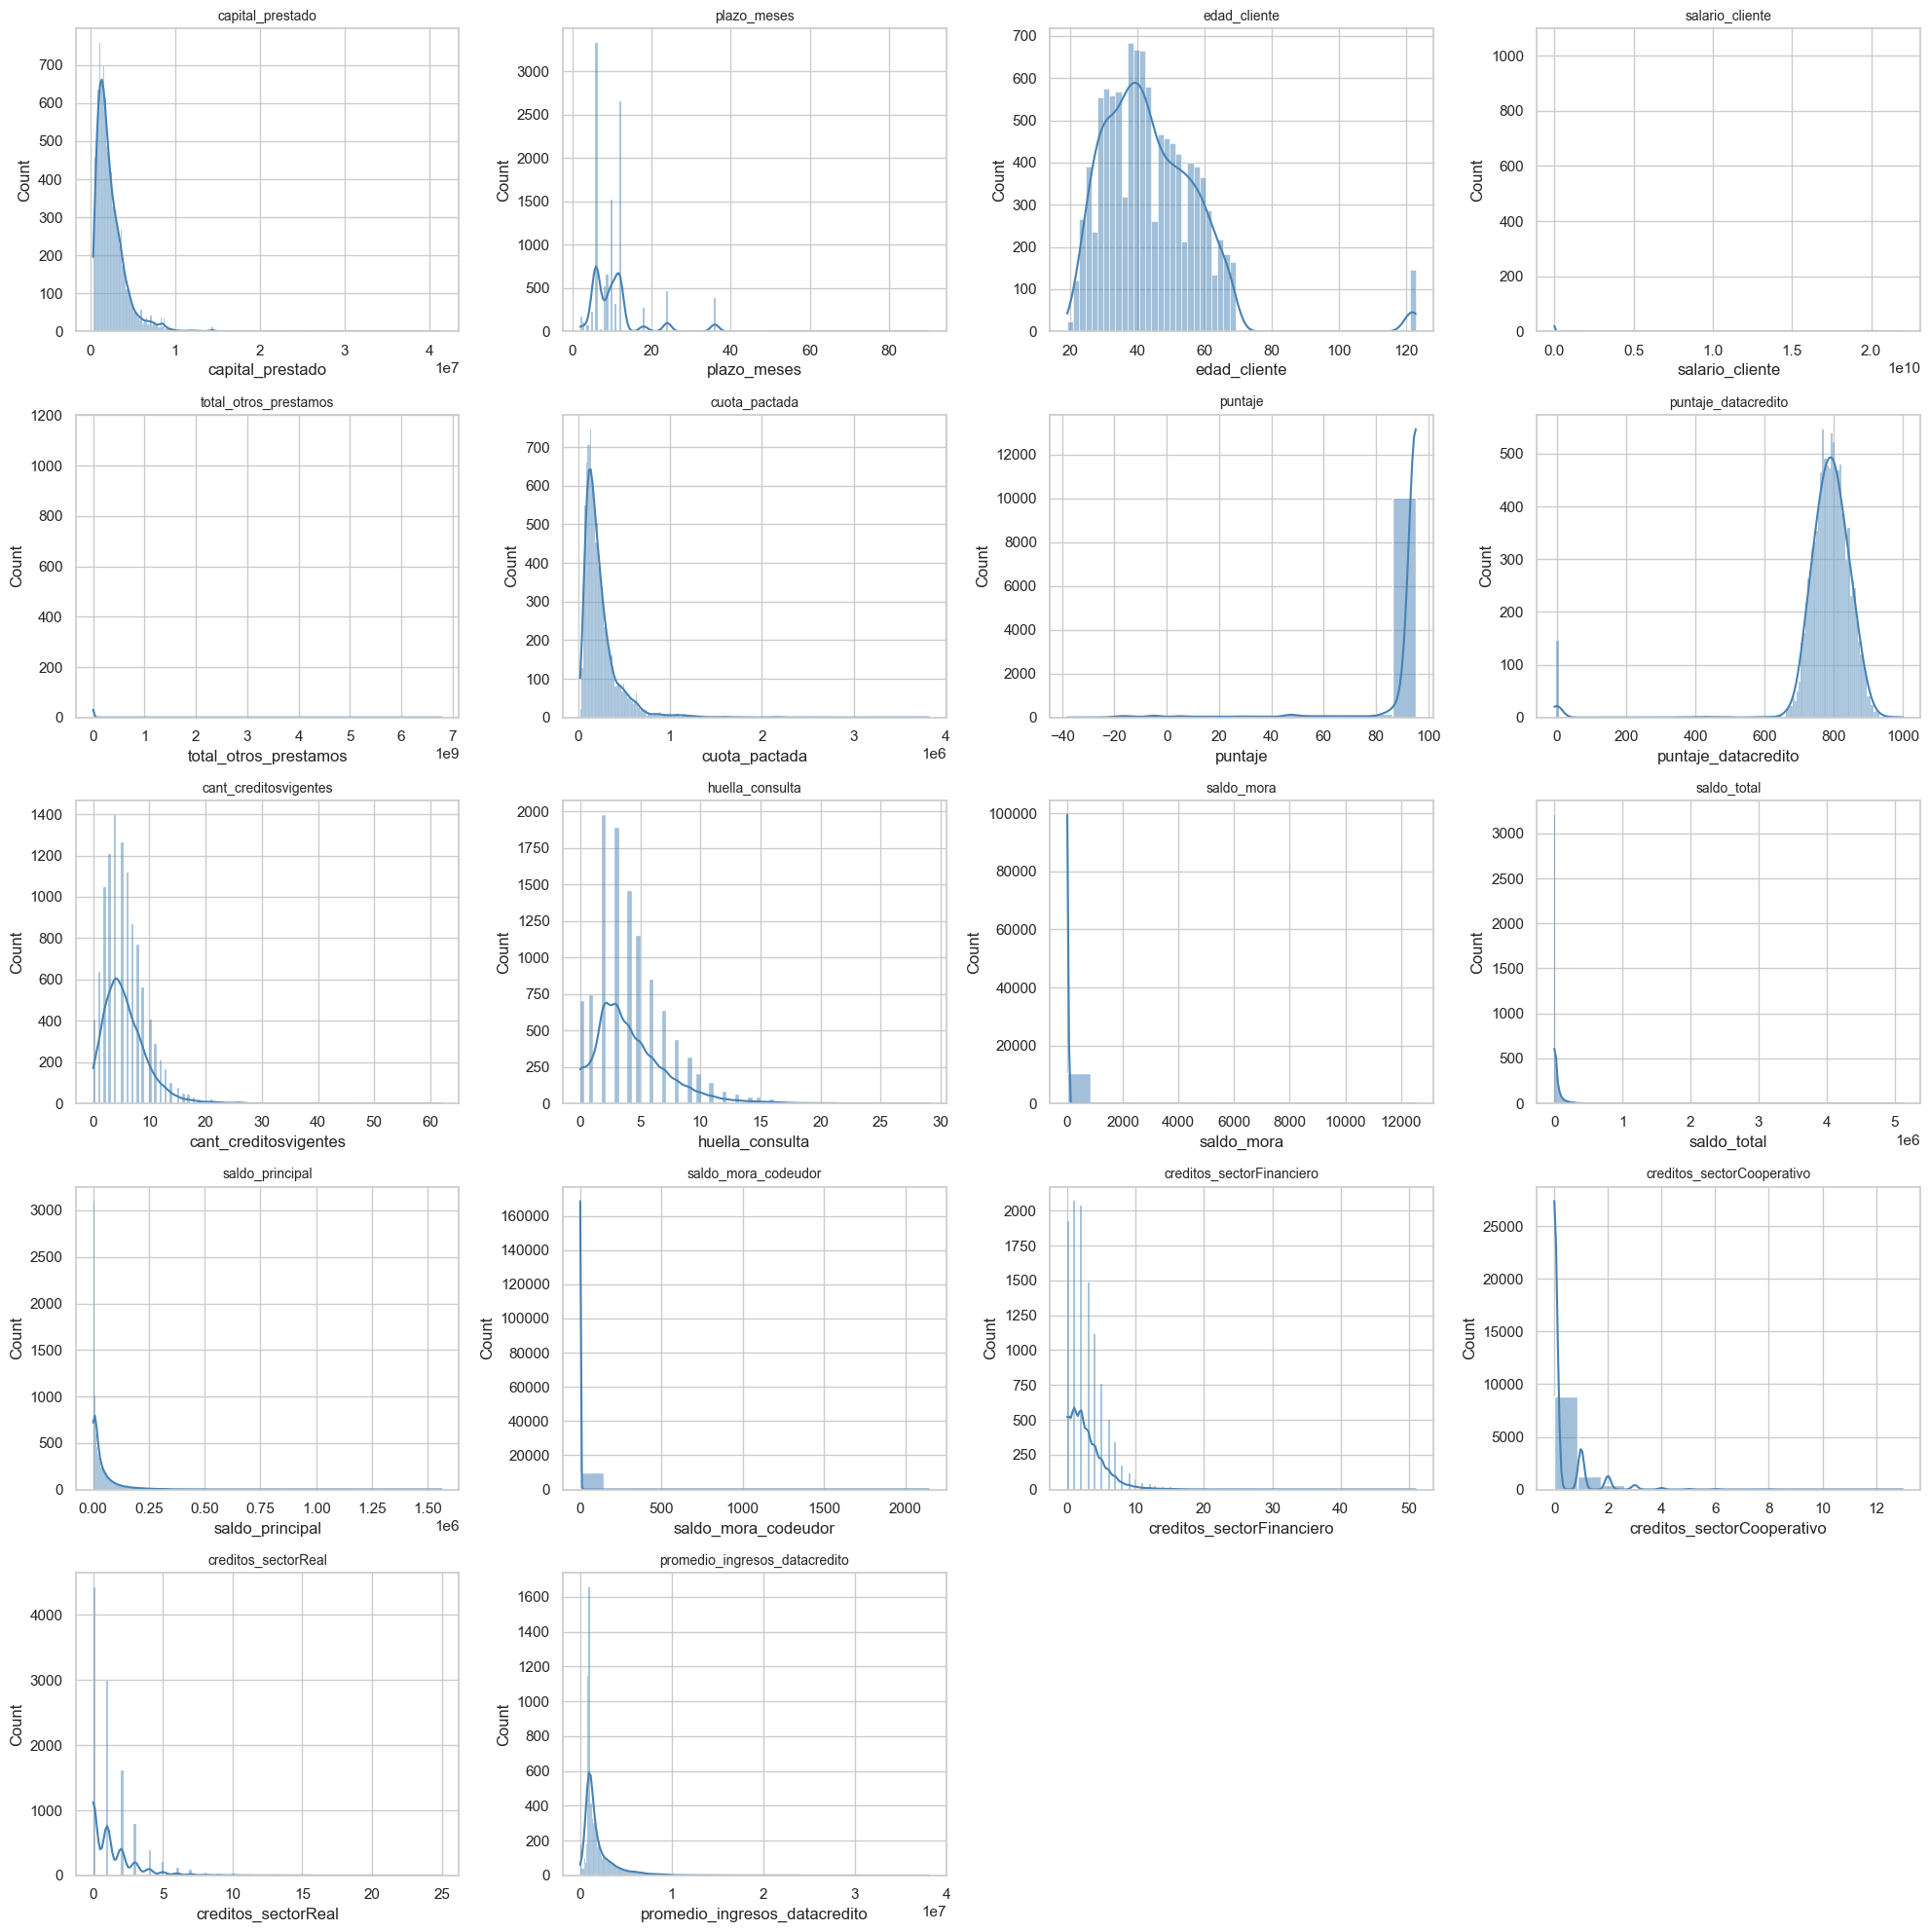

In [40]:
# ==========================================
# HISTOGRAMAS DE VARIABLES NUMÉRICAS
# ==========================================

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20,20))

axes = axes.flatten()

for i, variable in enumerate(variables_numericas_graficas):

    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        color="steelblue",
        ax=axes[i]
    )

    axes[i].set_title(variable, fontsize=10)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interpretación

Los histogramas muestran que la mayoría de las variables numéricas presentan distribuciones asimétricas, comportamiento frecuente en conjuntos de datos financieros.

- Las variables relacionadas con montos monetarios, como **capital_prestado**, **salario_cliente**, **total_otros_prestamos**, **cuota_pactada**, **saldo_total**, **saldo_principal**, **saldo_mora** y **promedio_ingresos_datacredito**, presentan una asimetría positiva. Esto indica que la mayor parte de los clientes registra valores relativamente bajos, mientras que un pequeño grupo concentra valores considerablemente superiores.

- Variables como **saldo_mora**, **saldo_mora_codeudor** y **saldo_total** presentan una alta concentración de registros cercanos a cero, es decir una proporción importante de los clientes no presenta mora o mantiene saldos bajos.

- La variable **edad_cliente** presenta una distribución relativamente más equilibrada que el resto de las variables, aunque se observan algunos valores extremos correspondientes a clientes de mayor edad.

- **puntaje_datacredito** presenta una distribución cercana a la normal, concentrando la mayor parte de los registros alrededor de valores próximos a 800.

- La variable **puntaje** muestra una fuerte concentración de observaciones en valores altos y algunos registros con valores negativos.

- Las variables de conteo, como **cant_creditosvigentes**, **huella_consulta**, **creditos_sectorFinanciero**, **creditos_sectorCooperativo** y **creditos_sectorReal**, presentan distribuciones discretas concentradas en valores bajos, comportamiento esperado para este tipo de atributos.

Las distribuciones observadas evidencian que varias variables presentan asimetría y posibles valores extremos, por lo que será necesario evaluar transformaciones y estrategias de tratamiento de outliers durante la fase de preparación de los datos antes del entrenamiento del modelo.

## 4.5 Identificación de valores atípicos (Outliers)

Los diagramas de caja (boxplots) permiten identificar la presencia de valores atípicos en cada variable numérica. En problemas de riesgo crediticio es común encontrar observaciones extremas asociadas a clientes con ingresos, deudas o montos de crédito significativamente superiores al promedio.

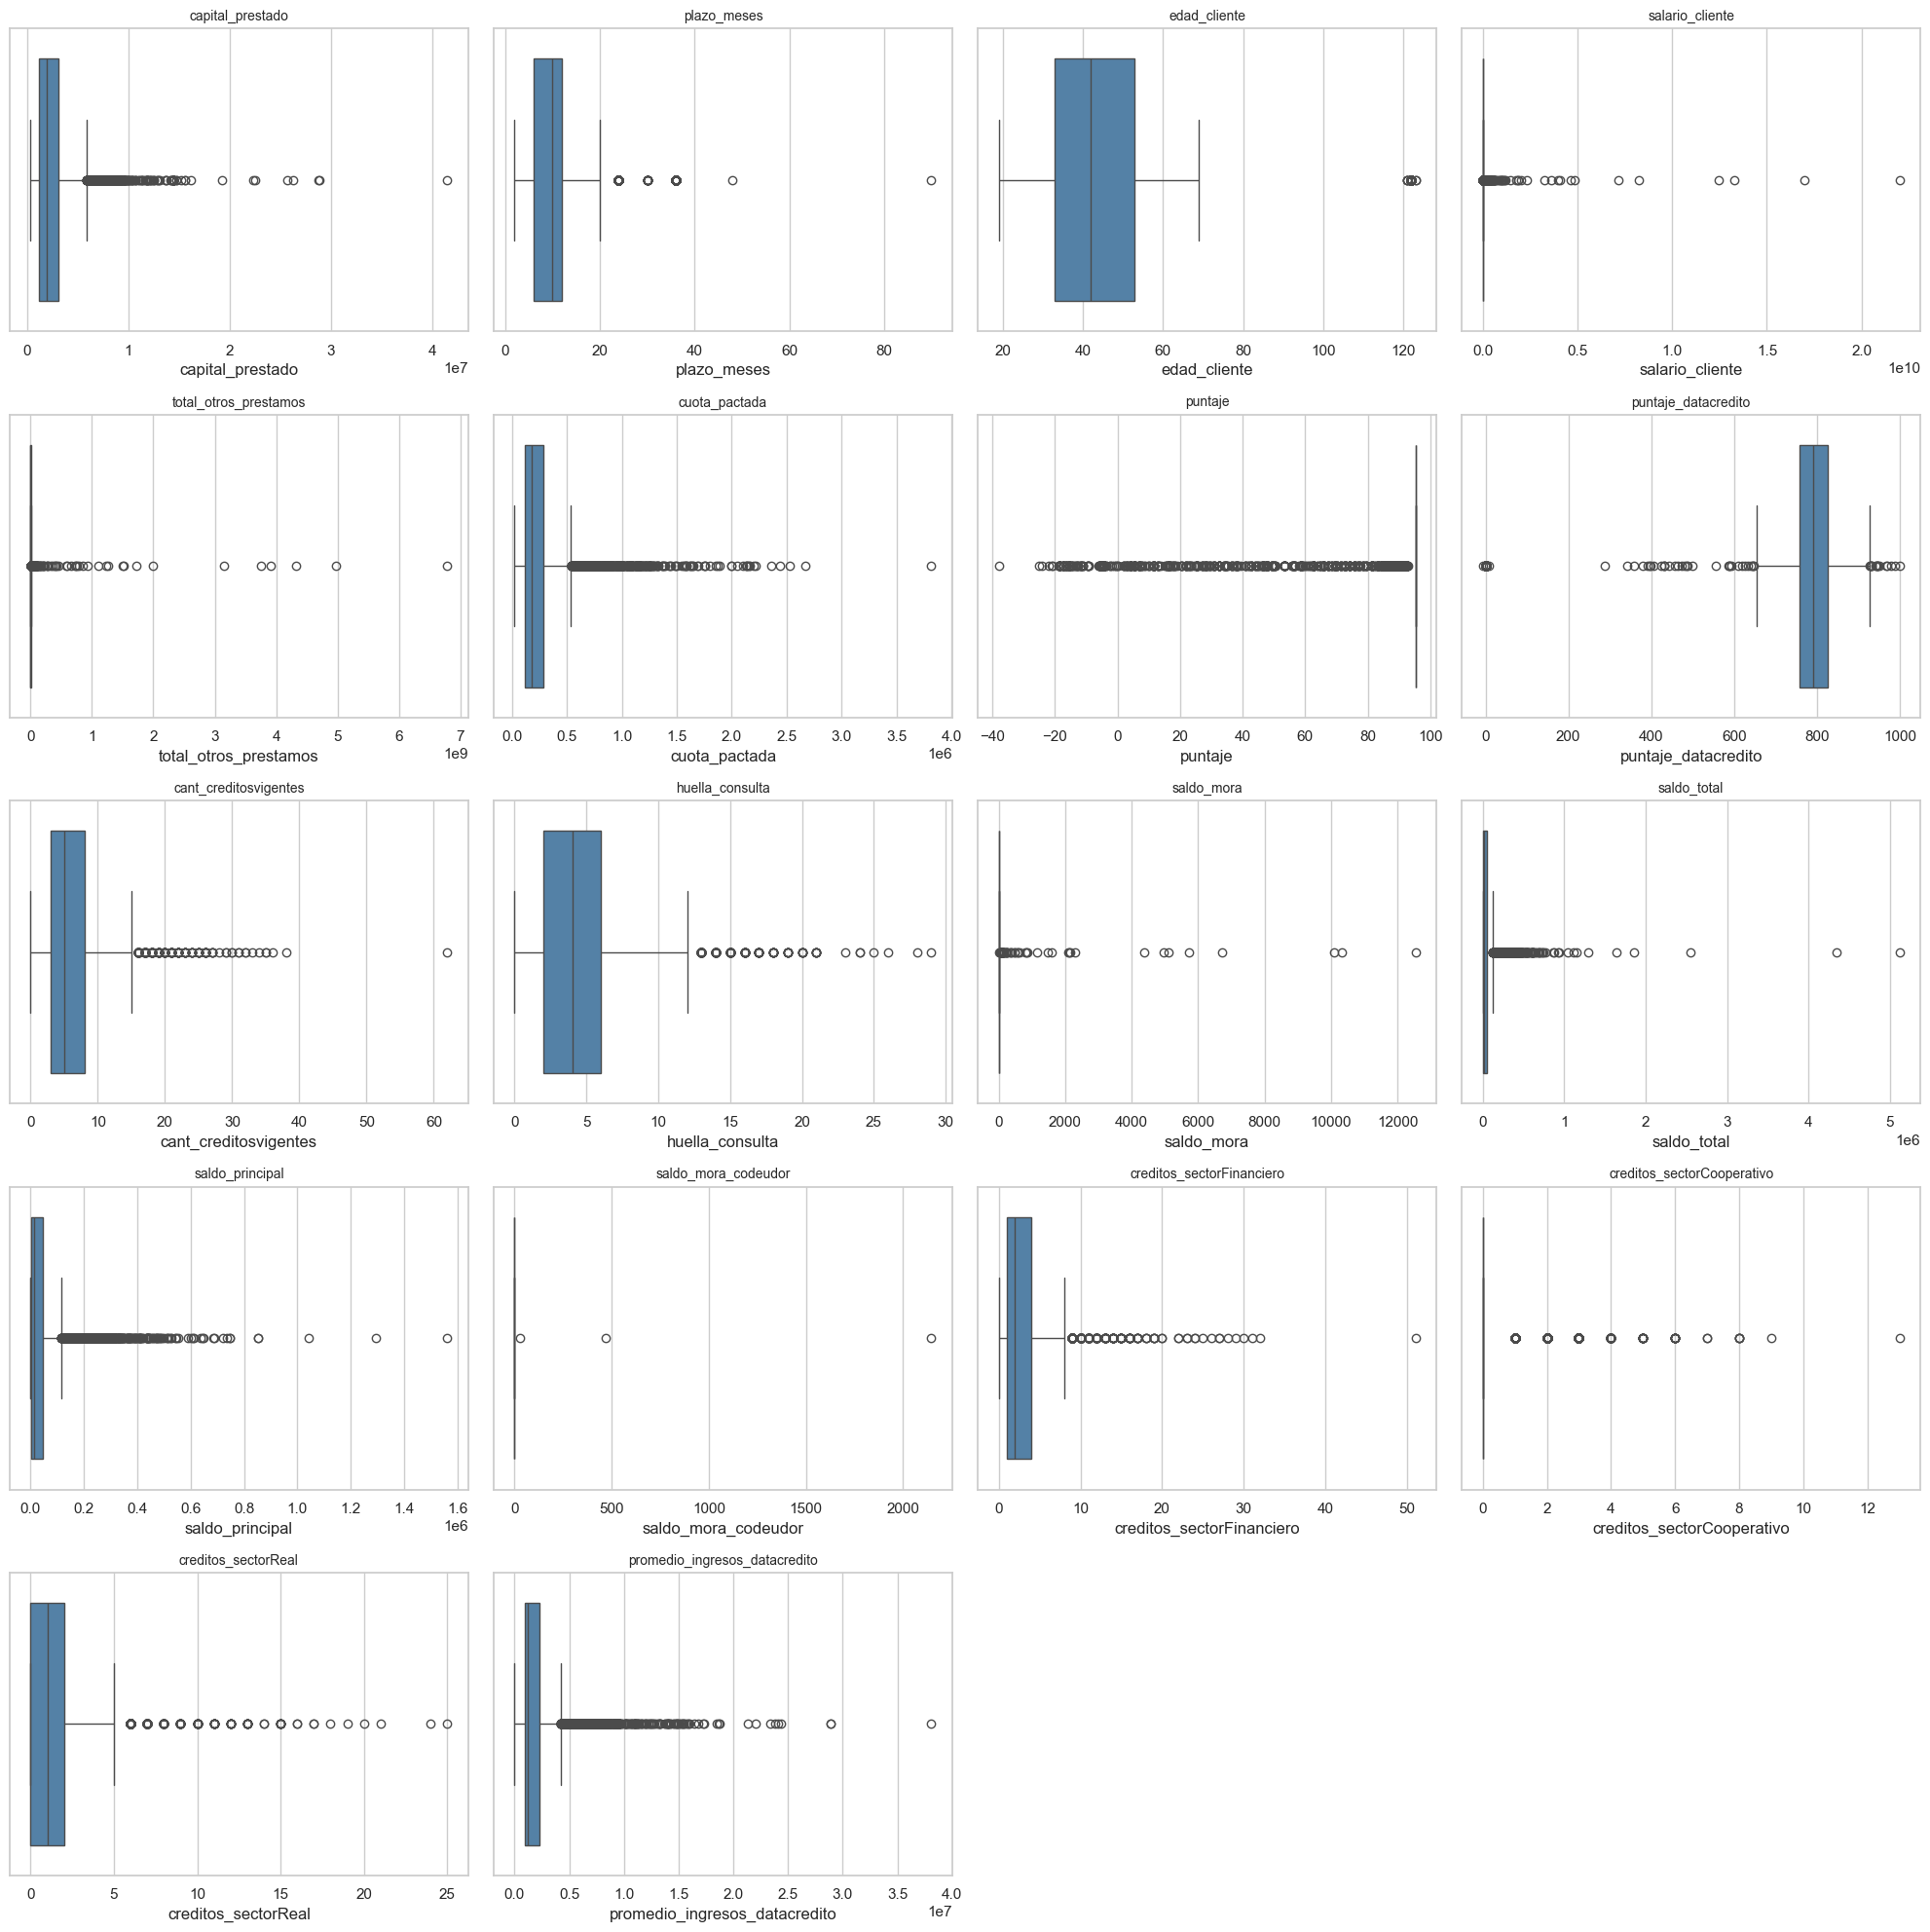

In [41]:
# ==========================================
# BOXPLOTS VARIABLES NUMÉRICAS
# ==========================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(20,20)
)

axes = axes.flatten()

for i, variable in enumerate(variables_numericas_graficas):

    sns.boxplot(
        x=df[variable],
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(variable, fontsize=10)

# Eliminar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interpretación

Los diagramas de caja muestran que varias variables presentan una cantidad importante de outliers, especialmente aquellas relacionadas con montos financieros.

- Variables como **capital_prestado**, **salario_cliente**, **total_otros_prestamos**, **cuota_pactada**, **saldo_total**, **saldo_principal** y **promedio_ingresos_datacredito** presentan numerosos valores extremos, donde un pequeño grupo de clientes puede concentrar montos significativamente superiores al promedio.

- **saldo_mora** y **saldo_mora_codeudor** presentan una alta concentración de observaciones en cero y pocos registros con valores elevados. la mayoría de los clientes no registra mora, mientras que un grupo reducido presenta saldos vencidos considerablemente altos.

- **edad_cliente** presenta una distribución estable con pocos valores atípicos correspondientes a clientes de mayor edad.

- Las variables **cant_creditosvigentes**, **huella_consulta** y los créditos por sector presentan algunos valores extremos; estos podrían corresponder a clientes con mayor actividad financiera.

- **puntaje_datacredito** presenta pocos valores atípicos y una distribución relativamente estable, mientras que la variable **puntaje** evidencia observaciones con valores negativos que deberán revisarse para determinar si corresponden a posibles inconsistencias.


## 4.6 Variables categóricas

En esta sección se analizan las variables categóricas del conjunto de datos mediante tablas de frecuencia y gráficos de barras, con el fin de comprender la distribución de cada categoría e identificar posibles desbalances entre ellas.

In [42]:
# ==========================================
# VARIABLES CATEGÓRICAS
# ==========================================

variables_categoricas = list(
    df.select_dtypes(include=["object"]).columns
)

# Agregar variables categóricas codificadas numéricamente
variables_categoricas.extend([
    "tipo_credito",
    "Pago_atiempo"
])

print("Variables categóricas:")

for variable in variables_categoricas:
    print("-", variable)

Variables categóricas:
- tipo_laboral
- tendencia_ingresos
- tipo_credito
- Pago_atiempo


In [43]:
# ==========================================
# TABLAS DE FRECUENCIA
# ==========================================

for variable in variables_categoricas:

    print("=" * 60)
    print(variable.upper())

    display(df[variable].value_counts(dropna=False))

TIPO_LABORAL


tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

TENDENCIA_INGRESOS


tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
75761             1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
4250635           1
146918            1
1123000           1
15090             1
10808             1
22363             1
-101368           1
86286             1
65988             1
77975             1
-288              1
54683             1
5697              1
122727            1
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
417087            1
209090            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
22832             1
-224714           1
Name: count, dtype: int64

TIPO_CREDITO


tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

PAGO_ATIEMPO


Pago_atiempo
1    10252
0      511
Name: count, dtype: int64

### Distribución de las variables categóricas (Countplots)

Los gráficos de barras permiten visualizar la frecuencia de cada categoría dentro de las variables categóricas del conjunto de datos. Este análisis facilita la identificación de posibles desbalances entre categorías y permite detectar inconsistencias o categorías poco representadas que podrían requerir tratamiento durante la preparación de los datos.

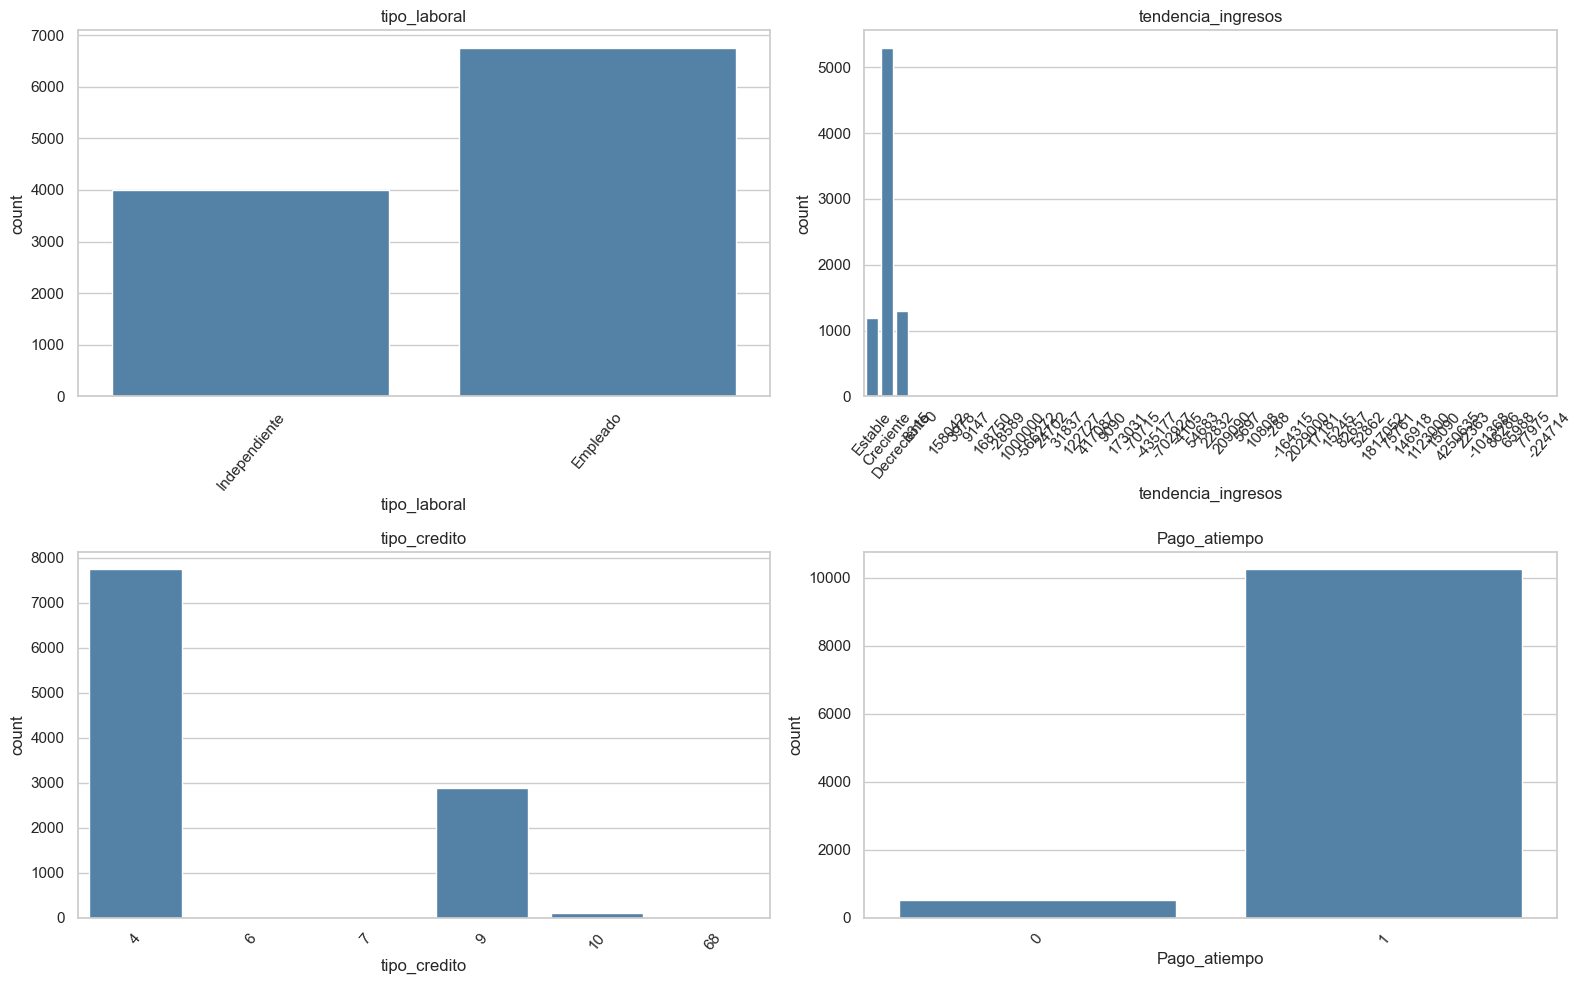

In [44]:
# ==========================================
# COUNTPLOTS VARIABLES CATEGÓRICAS
# ==========================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16,10)
)

axes = axes.flatten()

for i, variable in enumerate(variables_categoricas):

    sns.countplot(
        data=df,
        x=variable,
        ax=axes[i],
        color="steelblue"
    )

    axes[i].set_title(variable)
    axes[i].tick_params(axis='x', rotation=50)

plt.tight_layout()
plt.show()

### Interpretación

El análisis de las variables categóricas permitió identificar la distribución de las principales categorías presentes en el conjunto de datos y detectar posibles desbalances que deberán considerarse durante el desarrollo del modelo predictivo.

- **tipo_laboral** presenta únicamente dos categorías: *Empleado* (62,75%) e *Independiente* (37,25%), ambas categorías cuentan con una representación suficiente para su utilización en el entrenamiento del modelo.

- **tendencia_ingresos** evidencia una inconsistencia en la calidad de los datos. Además de las categorías esperadas (*Creciente*, *Decreciente* y *Estable*), la variable contiene valores numéricos positivos, negativos y registros faltantes, lo que indica una representación no uniforme de la información.

- **tipo_credito** presenta seis categorías codificadas numéricamente. Sin embargo, la distribución es desigual, concentrándose la mayoría de los registros en los códigos **4** y **9**, mientras que las demás categorías presentan muy pocos registros.

- **Pago_atiempo**, variable objetivo del proyecto, presenta un fuerte desbalance de clases. El **95,25%** de los registros corresponde a clientes que realizaron el pago oportunamente, mientras que únicamente el **4,75%** corresponde a clientes que incumplieron el pago. 

El análisis categórico permitió identificar tanto variables correctamente distribuidas como inconsistencias y desbalances que deberán ser tenidos en cuenta.

# 5. Análisis Bivariable

Se analizará la relación entre las variables predictoras y la variable objetivo **Pago_atiempo**, con el fin de identificar posibles patrones que permitan explicar el comportamiento de los clientes y evaluar qué variables podrían aportar información relevante para el modelo predictivo.

## 5.1 Variables categóricas vs variable objetivo (Pago_atiempo)

Se analiza la distribución del comportamiento de pago dentro de las principales variables categóricas del conjunto de datos, con el fin de identificar posibles diferencias entre los distintos grupos de clientes.

In [45]:
# ==========================================
# TIPO LABORAL VS PAGO A TIEMPO
# ==========================================

tabla_tipo_laboral = pd.crosstab(
    df["tipo_laboral"],
    df["Pago_atiempo"],
    normalize="index"
) * 100

tabla_tipo_laboral.round(2)

Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.29,95.71
Independiente,5.51,94.49


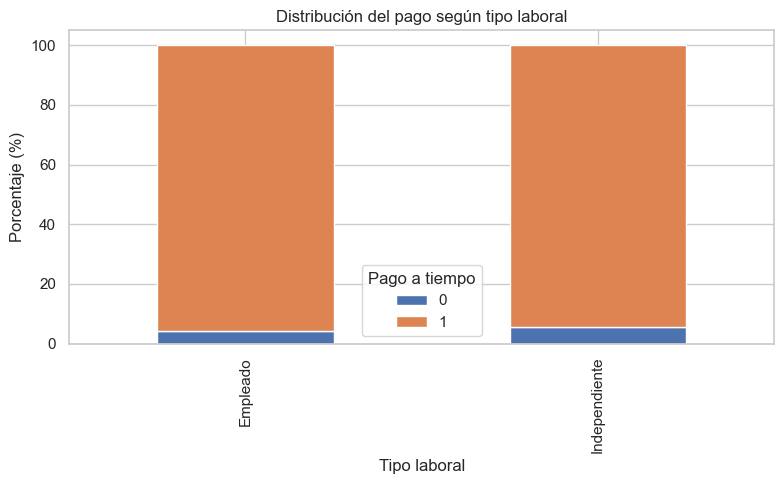

In [46]:
tabla_tipo_laboral.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Distribución del pago según tipo laboral")
plt.xlabel("Tipo laboral")
plt.ylabel("Porcentaje (%)")
plt.legend(title="Pago a tiempo")
plt.tight_layout()

plt.show()

### Interpretación

El comportamiento de pago es muy similar entre los clientes empleados e independientes, aunque los independientes muestran una ligera mayor proporción de incumplimiento (5.51% frente a 4.29%), la diferencia es reducida.

El **tipo laboral no parece ser una variable con una fuerte capacidad discriminante** para explicar el comportamiento de pago de los clientes.

In [47]:
# ==========================================
# TIPO DE CRÉDITO VS PAGO A TIEMPO
# ==========================================

tabla_tipo_credito = (
    pd.crosstab(
        df["tipo_credito"],
        df["Pago_atiempo"],
        normalize="index"
    ) * 100
)

tabla_tipo_credito.round(2)

Pago_atiempo,0,1
tipo_credito,,
4,4.69,95.31
6,42.86,57.14
7,0.00,100.00
9,4.73,95.27
10,2.59,97.41
68,0.00,100.00


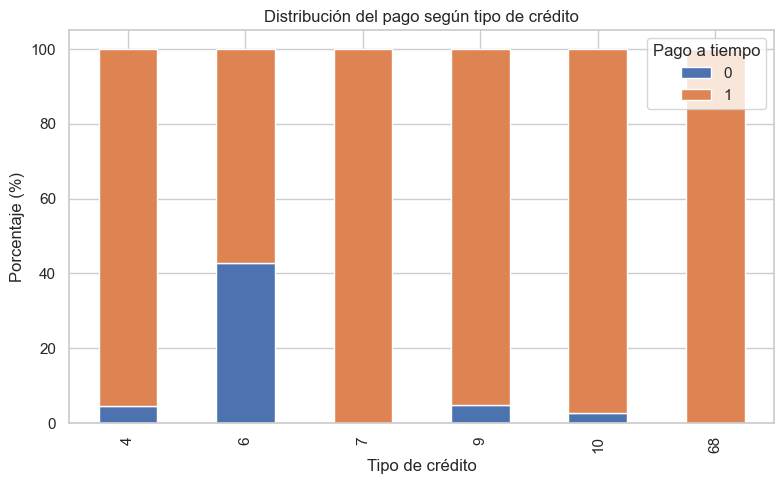

In [48]:
tabla_tipo_credito.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Distribución del pago según tipo de crédito")
plt.xlabel("Tipo de crédito")
plt.ylabel("Porcentaje (%)")
plt.legend(title="Pago a tiempo")

plt.tight_layout()
plt.show()

### Interpretación

El análisis muestra que los tipos de crédito **4** y **9**, que concentran la gran mayoría de las observaciones del conjunto de datos, presentan un comportamiento muy similar frente al pago oportuno, con porcentajes de incumplimiento cercanos al **5 %**.

Aunque el tipo de crédito **6** presenta una proporción considerablemente mayor de incumplimiento (42.86 %), esta categoría únicamente cuenta con **21 registros**, por lo que su comportamiento no puede considerarse estadísticamente representativo. De manera similar, los tipos **7** y **68** poseen un número muy reducido de observaciones, lo que impide extraer conclusiones confiables sobre su relación con el comportamiento de pago.

No se evidencian diferencias importantes entre los tipos de crédito con suficiente representación dentro del conjunto de datos.

## 5.2 Variables numéricas vs variable objetivo (Pago_atiempo)
En esta sección se analiza la distribución de las principales variables numéricas según el comportamiento de pago de los clientes.


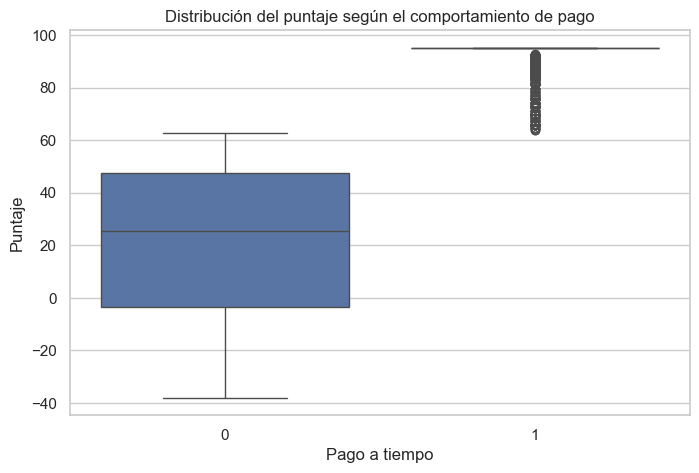

In [49]:
# ==========================================
# PUNTAJE VS PAGO A TIEMPO
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="puntaje"
)

plt.title("Distribución del puntaje según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Puntaje")

plt.show()

### Interpretación

El puntaje presenta una diferencia muy marcada entre los clientes que realizan sus pagos oportunamente y aquellos que presentan incumplimiento.

Los clientes con **Pago_atiempo = 1** concentran la mayor parte de sus observaciones en valores cercanos al máximo puntaje registrado, mostrando una distribución poco dispersa y con una mediana considerablemente superior.

Por el contrario, los clientes con **Pago_atiempo = 0** presentan puntajes menores y una mayor variabilidad, incluyendo valores negativos y una dispersión mucho más amplia.

Estos resultados indican que el **puntaje** posee una fuerte capacidad para diferenciar ambos grupos de clientes.

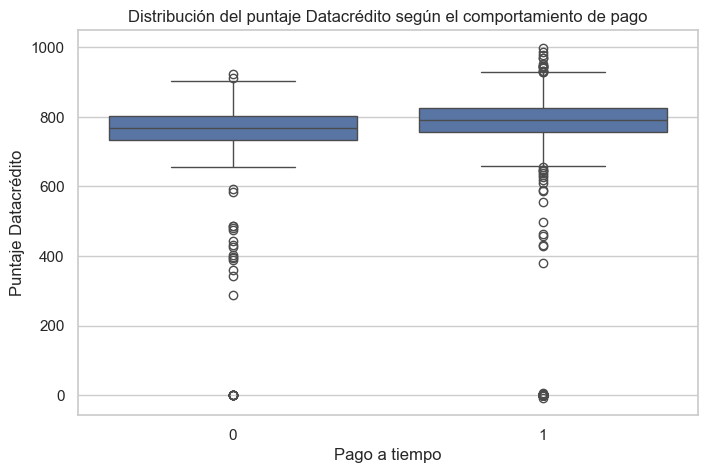

In [50]:
# ==========================================
# PUNTAJE DATACRÉDITO VS PAGO A TIEMPO
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="puntaje_datacredito"
)

plt.title("Distribución del puntaje Datacrédito según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Puntaje Datacrédito")

plt.show()

### Interpretación

El puntaje Datacrédito presenta diferencias entre los clientes que pagan oportunamente y aquellos que incumplen, aunque estas diferencias son menos marcadas que las observadas en la variable puntaje.

Los clientes con **Pago_atiempo = 1** muestran una mediana ligeramente superior y una distribución desplazada hacia valores más altos del puntaje Datacrédito. Sin embargo, existe un importante solapamiento entre ambos grupos, indicando que clientes con puntajes similares pueden presentar comportamientos de pago diferentes.

En comparación con la variable puntaje, el puntaje Datacrédito parece tener una menor capacidad para discriminar el comportamiento de pago cuando se analiza de manera individual.

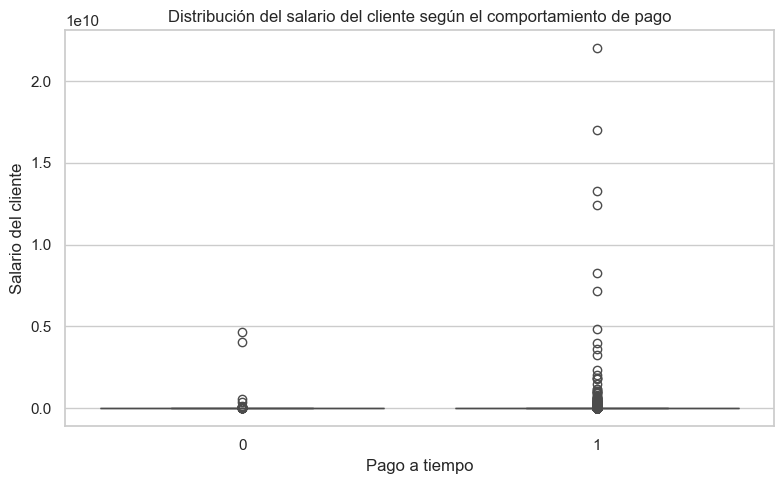

In [51]:
# ==========================================
# SALARIO DEL CLIENTE VS PAGO A TIEMPO
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="salario_cliente"
)

plt.title("Distribución del salario del cliente según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Salario del cliente")

plt.tight_layout()
plt.show()

### Observación

La variable **salario_cliente** presenta valores atípicos extremadamente altos que dificultan la interpretación de la distribución mediante un diagrama de caja convencional. Por esta razón, la visualización se ajusta limitando el eje vertical al percentil 99, con el fin de facilitar la comparación entre ambos grupos sin modificar los datos originales.

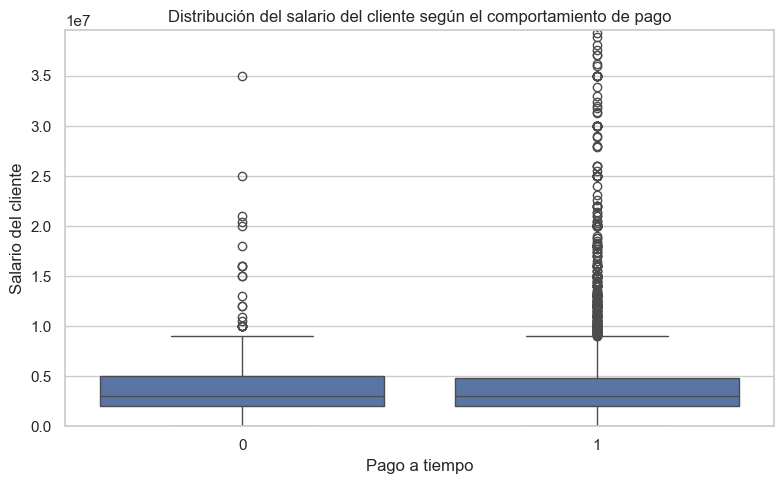

In [52]:
# ==========================================
# SALARIO DEL CLIENTE VS PAGO A TIEMPO
# (Visualización ajustada)
# ==========================================

limite_superior = df["salario_cliente"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="salario_cliente"
)

plt.ylim(0, limite_superior)

plt.title("Distribución del salario del cliente según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Salario del cliente")

plt.tight_layout()
plt.show()

### Interpretación

Una vez ajustada la visualización para reducir el efecto de los valores extremos, se observa que la distribución del salario es muy similar entre los clientes que realizan sus pagos oportunamente y aquellos que presentan incumplimiento.

La variable presenta una gran cantidad de valores atípicos, especialmente en el grupo de clientes que pagan oportunamente, confirmando la fuerte asimetría observada durante el análisis univariable.

El **salario_cliente** no parece ser una variable con una alta capacidad discriminante cuando se analiza de forma individual.

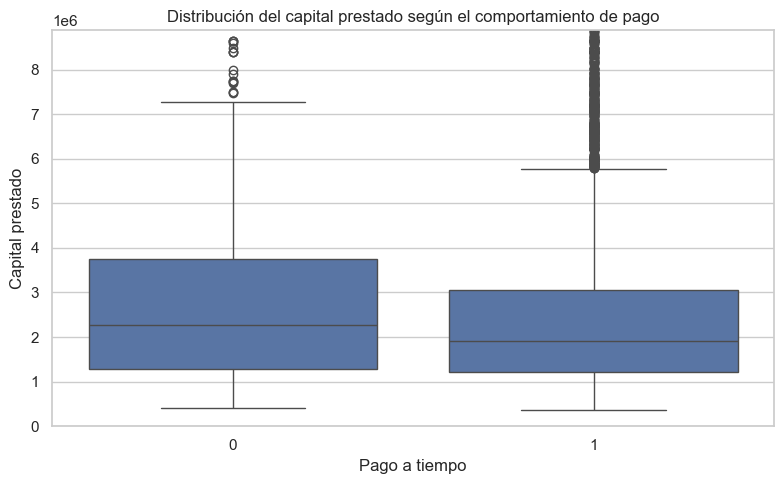

In [53]:
# ==========================================
# CAPITAL PRESTADO VS PAGO A TIEMPO
# ==========================================

limite_superior = df["capital_prestado"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="capital_prestado"
)

plt.ylim(0, limite_superior)

plt.title("Distribución del capital prestado según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Capital prestado")

plt.tight_layout()
plt.show()

### Interpretación

El capital prestado presenta diferencias moderadas entre los clientes que realizan sus pagos oportunamente y aquellos que incumplen.

Los clientes con **Pago_atiempo = 0** muestran una mediana ligeramente superior, lo que sugiere que los créditos de mayor valor podrían estar asociados con un incremento del riesgo de incumplimiento.

No obstante, existe una cantidad considerable de valores atípicos en las dos categorías, especialmente entre los clientes que realizaron sus pagos oportunamente.

Aunque el **capital_prestado** podría aportar información para la predicción del riesgo crediticio, su capacidad discriminante es inferior a la observada en variables como **puntaje** y **puntaje_datacredito**.

Text(0, 0.5, 'Edad del cliente')

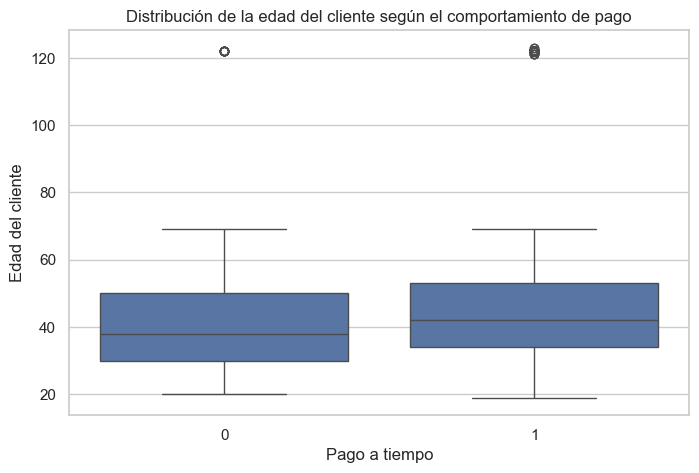

In [54]:
# ==========================================
# EDAD DEL CLIENTE VS PAGO A TIEMPO
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="edad_cliente"
)

plt.title("Distribución de la edad del cliente según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Edad del cliente")


### Interpretación

Los clientes que pagan a tiempo presentan una edad mediana ligeramente superior a la de quienes incumplen, lo que sugiere que los clientes de mayor edad tienden a mostrar un mejor comportamiento de pago. Sin embargo, existe un amplio solapamiento entre ambos grupos, por lo que la edad, por sí sola, no parece ser un factor determinante para explicar el riesgo crediticio. Además, se identificó un valor atípico cercano a los 122 años.

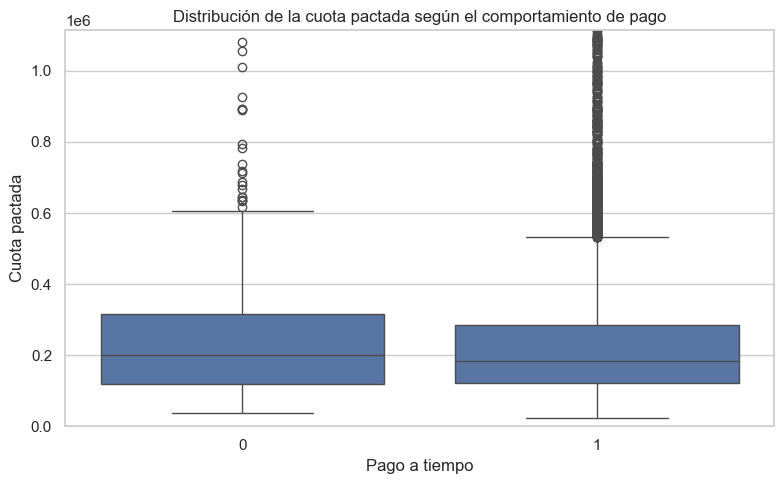

In [55]:
# ==========================================
# CUOTA PACTADA VS PAGO A TIEMPO
# ==========================================

limite_superior = df["cuota_pactada"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="cuota_pactada"
)

plt.ylim(0, limite_superior)

plt.title("Distribución de la cuota pactada según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Cuota pactada")

plt.tight_layout()
plt.show()

### Interpretación

La distribución de la **cuota pactada** es muy similar entre los clientes que pagan a tiempo y aquellos que presentan incumplimiento. Aunque los clientes que no pagan a tiempo muestran una mediana ligeramente superior, existe un amplio solapamiento entre ambos grupos. 
Además, se observan numerosos valores atípicos con cuotas elevadas en ambas categorías, especialmente entre los clientes que pagan oportunamente.

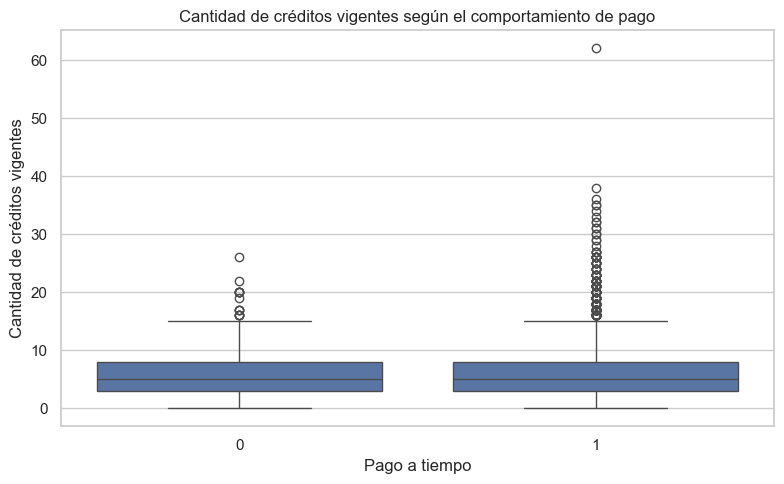

In [57]:
# ==========================================
# CANTIDAD DE CRÉDITOS VIGENTES VS PAGO A TIEMPO
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="cant_creditosvigentes"
)

plt.title("Cantidad de créditos vigentes según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Cantidad de créditos vigentes")

plt.tight_layout()
plt.show()

### Interpretación

La distribución de la **cantidad de créditos vigentes** es muy similar entre los clientes que pagan a tiempo y aquellos que presentan incumplimiento, con una mediana cercana a cinco créditos en ambos grupos. Aunque los clientes que pagan oportunamente presentan una mayor cantidad de valores atípicos, no se observan diferencias significativas entre las distribuciones.

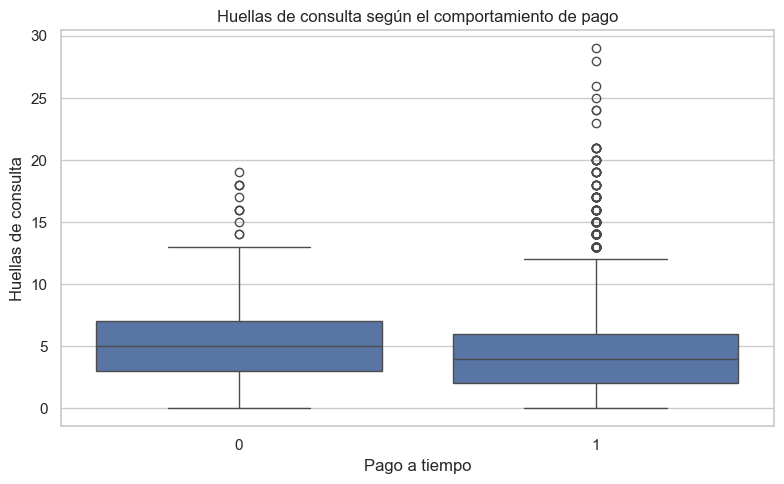

In [58]:
# ==========================================
# HUELLAS DE CONSULTA VS PAGO A TIEMPO
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="huella_consulta"
)

plt.title("Huellas de consulta según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Huellas de consulta")

plt.tight_layout()
plt.show()

### Interpretación

La distribución de las **huellas de consulta** es muy similar entre los clientes que pagan a tiempo y aquellos que presentan incumplimiento, con una mediana cercana a cuatro consultas en ambos grupos. Los clientes que pagan oportunamente presentan una mayor cantidad de valores atípicos, alcanzando un número considerablemente más alto de consultas. 

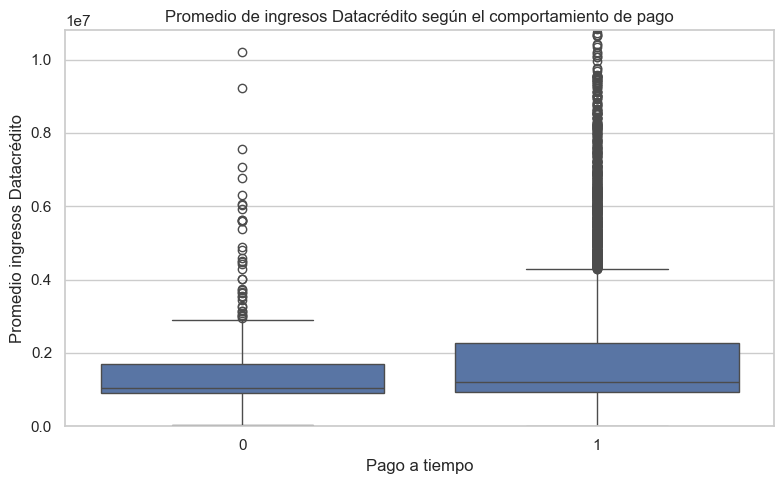

In [59]:
# ==========================================
# PROMEDIO INGRESOS DATACRÉDITO VS PAGO A TIEMPO
# ==========================================

limite_superior = df["promedio_ingresos_datacredito"].quantile(0.99)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pago_atiempo",
    y="promedio_ingresos_datacredito"
)

plt.ylim(0, limite_superior)

plt.title("Promedio de ingresos Datacrédito según el comportamiento de pago")

plt.xlabel("Pago a tiempo")
plt.ylabel("Promedio ingresos Datacrédito")

plt.tight_layout()
plt.show()

### Interpretación

El **promedio de ingresos reportados en Datacrédito** es ligeramente mayor en los clientes que pagan a tiempo en comparación con aquellos que presentan incumplimiento. Además, este grupo muestra una mayor dispersión y una cantidad considerable de valores atípicos con ingresos elevados. Aunque los clientes con mayores ingresos tienden a presentar un mejor comportamiento de pago, existe un amplio solapamiento entre ambos grupos.

# 6. Análisis Multivariable

El análisis multivariable permite estudiar la relación entre varias variables numéricas de manera simultánea, identificando posibles asociaciones y patrones que no son evidentes en los análisis univariables o bivariables.

En esta sección se utiliza una matriz de correlación para evaluar el grado de relación lineal entre las variables numéricas del conjunto de datos.

### 6.1 Matriz de correlación

In [60]:
# ==========================================
# MATRIZ DE CORRELACIÓN
# ==========================================

variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns

variables_numericas

Index(['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente',
       'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje',
       'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta',
       'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
       'creditos_sectorFinanciero', 'creditos_sectorCooperativo',
       'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo'],
      dtype='object')

In [61]:
correlacion = df[variables_numericas].corr(numeric_only=True)

correlacion.round(2)

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
tipo_credito,1.00,0.02,-0.14,0.14,0.04,0.06,0.06,0.00,-0.13,0.04,-0.04,0.04,0.10,0.14,0.02,0.06,-0.01,0.01,0.06,0.00
capital_prestado,0.02,1.00,0.30,0.13,0.05,0.07,0.76,-0.04,-0.15,0.05,0.03,0.03,0.14,0.18,-0.01,0.11,-0.02,-0.08,0.12,-0.04
plazo_meses,-0.14,0.30,1.00,-0.09,-0.01,-0.01,-0.23,-0.07,0.00,-0.00,0.05,0.02,-0.03,-0.05,-0.00,-0.00,0.03,-0.00,0.02,-0.06
edad_cliente,0.14,0.13,-0.09,1.00,0.15,0.20,0.15,0.03,-0.38,-0.04,-0.24,0.03,0.05,0.08,0.02,0.01,-0.00,-0.05,0.03,0.03
salario_cliente,0.04,0.05,-0.01,0.15,1.00,0.60,0.05,-0.00,-0.19,-0.04,-0.04,0.00,0.00,0.01,-0.00,-0.02,-0.01,-0.03,-0.00,-0.00
total_otros_prestamos,0.06,0.07,-0.01,0.20,0.60,1.00,0.06,-0.01,-0.28,-0.05,-0.05,0.01,0.08,0.11,-0.00,-0.03,-0.01,-0.03,0.02,-0.01
cuota_pactada,0.06,0.76,-0.23,0.15,0.05,0.06,1.00,-0.01,-0.13,0.05,0.00,0.00,0.15,0.20,-0.01,0.11,-0.03,-0.07,0.09,-0.01
puntaje,0.00,-0.04,-0.07,0.03,-0.00,-0.01,-0.01,1.00,0.09,0.01,-0.08,-0.10,0.01,0.01,0.00,0.03,0.03,-0.02,0.05,0.92
puntaje_datacredito,-0.13,-0.15,0.00,-0.38,-0.19,-0.28,-0.13,0.09,1.00,0.11,0.02,-0.19,0.07,0.08,0.00,0.15,0.03,-0.05,0.12,0.07
cant_creditosvigentes,0.04,0.05,-0.00,-0.04,-0.04,-0.05,0.05,0.01,0.11,1.00,0.32,0.01,0.40,0.49,-0.01,0.79,0.20,0.54,0.16,0.01


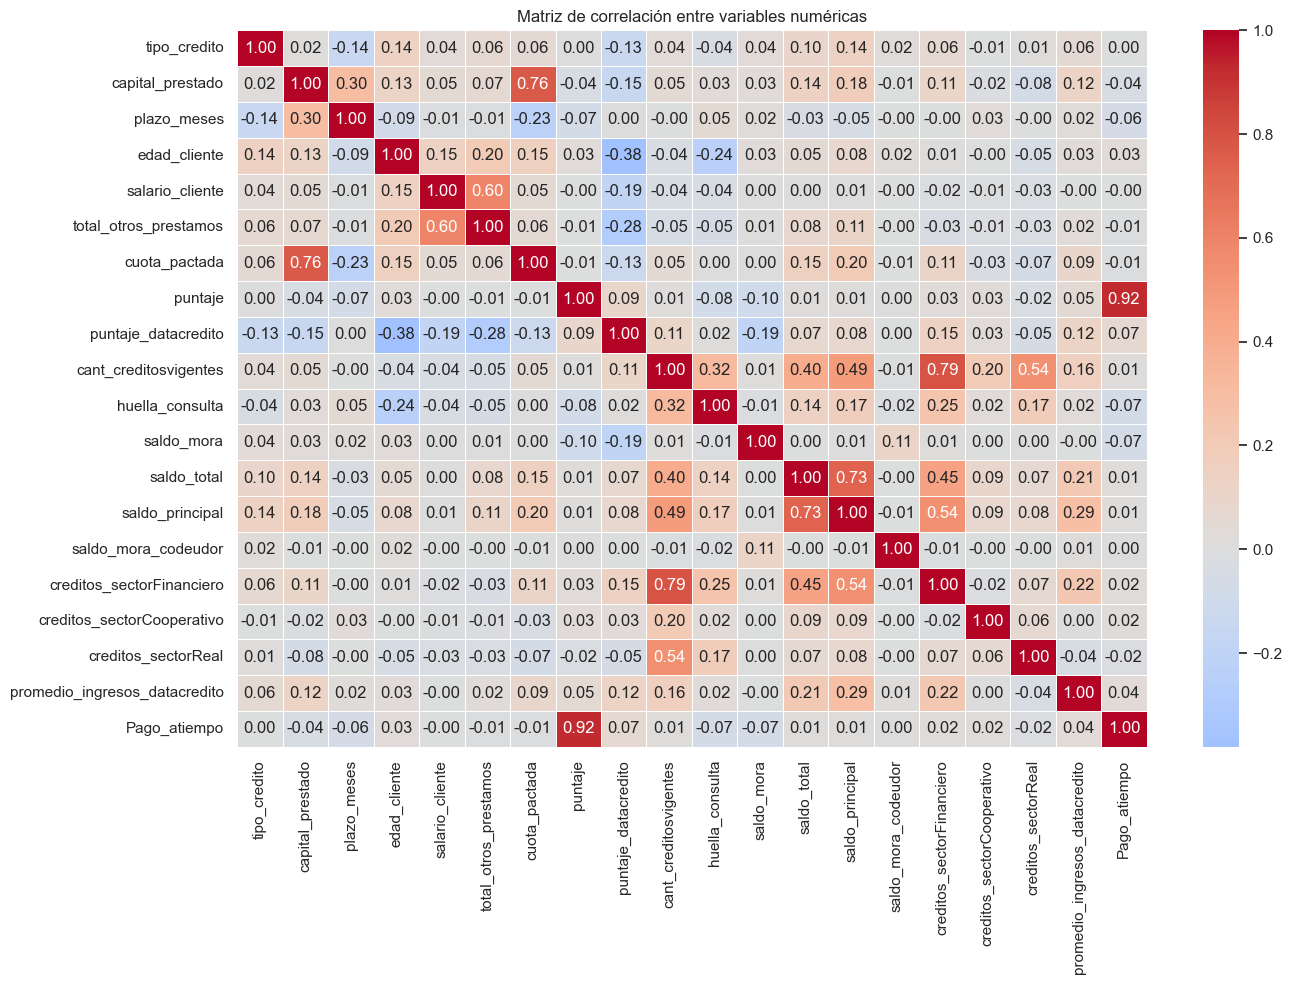

In [62]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")

plt.tight_layout()
plt.show()

In [66]:
# ==========================================
# PARES DE VARIABLES MÁS CORRELACIONADAS
# ==========================================

correlaciones_altas = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
)

correlaciones_altas.columns = [
    "Variable 1",
    "Variable 2",
    "Correlación"
]

correlaciones_altas

,Variable 1,Variable 2,Correlación
0,puntaje,Pago_atiempo,0.923134
1,cant_creditosvigentes,creditos_sectorFinanciero,0.791253
2,capital_prestado,cuota_pactada,0.764104
3,saldo_total,saldo_principal,0.734664
4,salario_cliente,total_otros_prestamos,0.596990
5,cant_creditosvigentes,creditos_sectorReal,0.540677
6,saldo_principal,creditos_sectorFinanciero,0.537307
7,cant_creditosvigentes,saldo_principal,0.485953
8,saldo_total,creditos_sectorFinanciero,0.451957
9,cant_creditosvigentes,saldo_total,0.402105


### Interpretación

La matriz de correlación permitió identificar las principales relaciones lineales entre las variables numéricas del conjunto de datos.

La correlación más alta se presentó entre **puntaje** y **Pago_atiempo** (0.92), indicando que el puntaje es una de las variables con mayor relación respecto al comportamiento de pago, resultado que coincide con lo observado durante el análisis bivariable.

También se identificaron correlaciones altas entre **cantidad de créditos vigentes** y **créditos del sector financiero** (0.79), así como entre **capital prestado** y **cuota pactada** (0.76). Estas relaciones son coherentes desde el punto de vista del negocio, ya que un mayor número de créditos suele estar asociado con una mayor participación en el sector financiero y un mayor capital prestado generalmente implica cuotas mensuales más elevadas.

De igual forma, **saldo_total** y **saldo_principal** presentan una correlación alta (0.73), lo que indica que ambas variables contienen información muy similar y podrían aportar información redundante durante el entrenamiento del modelo.

En términos generales, la mayoría de las variables presentan correlaciones bajas o moderadas entre sí, lo que sugiere que el conjunto de datos conserva información diversa y útil para el desarrollo del modelo predictivo.

### 6.2 Relación entre las variables más importantes

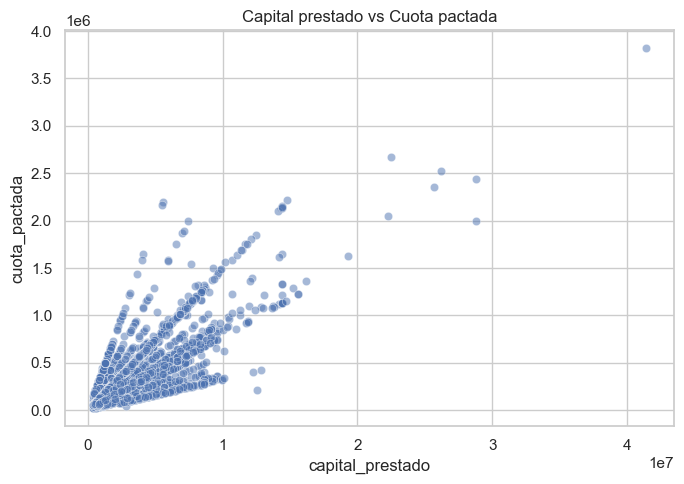

In [68]:
# ==========================================
# CAPITAL PRESTADO VS CUOTA PACTADA
# ==========================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="capital_prestado",
    y="cuota_pactada",
    alpha=0.5
)

plt.title("Capital prestado vs Cuota pactada")

plt.tight_layout()
plt.show()

### Interpretación
El diagrama de dispersión muestra una relación positiva entre el capital prestado y la cuota pactada: a medida que aumenta el monto del préstamo, también tiende a aumentar el valor de la cuota. Sin embargo, existe una alta dispersión en los datos, lo que indica que clientes con un mismo capital pueden tener cuotas diferentes, posiblemente debido a factores como el plazo, la tasa de interés o las condiciones del crédito. También se observan algunos valores atípicos correspondientes a préstamos y cuotas de montos muy elevados.

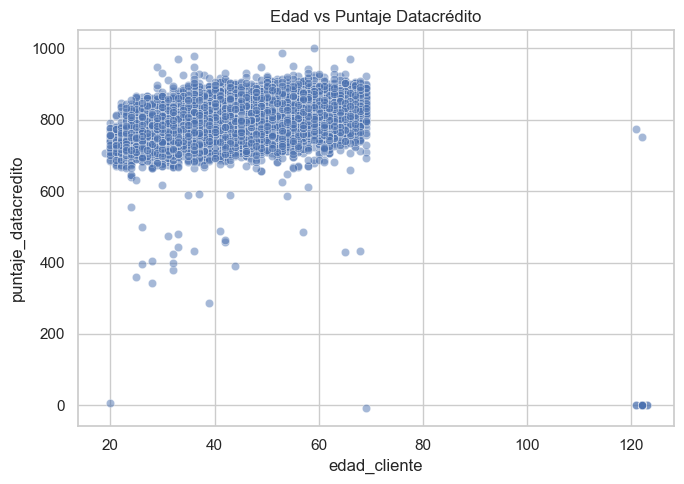

In [69]:
# ==========================================
# PUNTAJE DATACREDITO VS EDAD
# ==========================================

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="edad_cliente",
    y="puntaje_datacredito",
    alpha=0.5
)

plt.title("Edad vs Puntaje Datacrédito")

plt.tight_layout()
plt.show()

### Interpretación
El diagrama de dispersión muestra que no existe una relación clara entre la edad del cliente y el puntaje de Datacrédito. La mayoría de los clientes, independientemente de su edad, tienen puntajes concentrados entre 700 y 900 puntos. Además, se observan algunos valores atípicos

6.3 Scatter

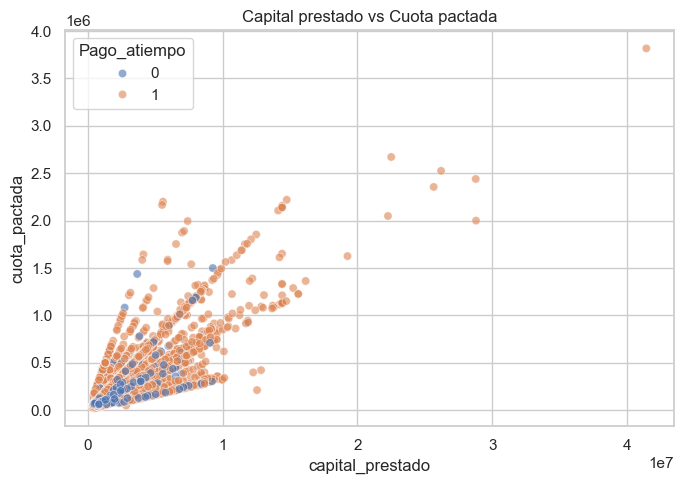

In [70]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="capital_prestado",
    y="cuota_pactada",
    hue="Pago_atiempo",
    alpha=0.6
)

plt.title("Capital prestado vs Cuota pactada")

plt.tight_layout()
plt.show()

### Interpretación
El gráfico muestra una relación positiva entre el capital prestado y la cuota pactada: a mayor monto del préstamo, mayor suele ser la cuota. Además, los clientes que pagan a tiempo (1) se concentran en préstamos de mayor valor y presentan más casos de cuotas altas, mientras que los clientes que no pagan a tiempo (0) se ubican principalmente en montos menores. Sin embargo, existe un amplio solapamiento entre ambos grupos, por lo que el capital prestado y la cuota pactada, por sí solos, no permiten diferenciar claramente el comportamiento de pago.

## 7. Reglas de validación identificadas

Durante el análisis exploratorio se identificaron algunas condiciones que deberán validarse durante la etapa de preparación de datos:

- Revisar registros con edades superiores a 100 años, ya que podrían corresponder a errores de captura.
- Verificar los valores inconsistentes encontrados en la variable tendencia_ingresos y unificarlos en las categorías válidas.
- Analizar el tratamiento de los valores atípicos presentes en variables como salario_cliente, capital_prestado, cuota_pactada y promedio_ingresos_datacredito.
- Confirmar que variables altamente correlacionadas como saldo_total y saldo_principal no generen redundancia durante el entrenamiento del modelo.
- Verificar la consistencia de los valores faltantes antes de la etapa de modelado.

## 8. Transformaciones identificadas

Con base en el análisis exploratorio, se consideran las siguientes transformaciones para la etapa de preparación de datos:

- Imputación de valores faltantes en variables numéricas y categóricas.
- Codificación de variables categóricas para su utilización en algoritmos de aprendizaje automático.
- Escalamiento o normalización de variables numéricas cuando el algoritmo lo requiera.
- Tratamiento de valores atípicos mediante técnicas apropiadas.
- Evaluación de eliminación de variables altamente correlacionadas para reducir redundancia.

## 9. Posibles atributos derivados

Durante el análisis se identificaron algunas variables que podrían construirse en etapas posteriores para mejorar la capacidad predictiva del modelo:

- Relación entre cuota pactada y salario del cliente.
- Relación entre capital prestado y promedio de ingresos.
- Número total de créditos por sector.
- Indicadores de endeudamiento del cliente.